FINDING DBS STIMULATION ARTIFACTS - WORKING VERSION
Base DBS range: 100-250 Hz (adjusted for Nyquist)
⏱️  MUST OCCUR IN FIRST 120 SECONDS
Amplitude Z-score: 4.0σ
Power Z-score: 3.0σ
Periodicity: 0.15
Min burst duration: 0.5s
Found 12 EEG recordings

[1/12] Processing: PD_001_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 801.2s
      DBS range for 500.0Hz: 100-250 Hz

[2/12] Processing: PD_002_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 742.9s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 188.0 Hz, Chan: 95
      Amp Z: 382.8σ, Power Z: 23.8σ
      Periodicity: 0.22, Score: 19649.1
      Onset: 13.978s ✓


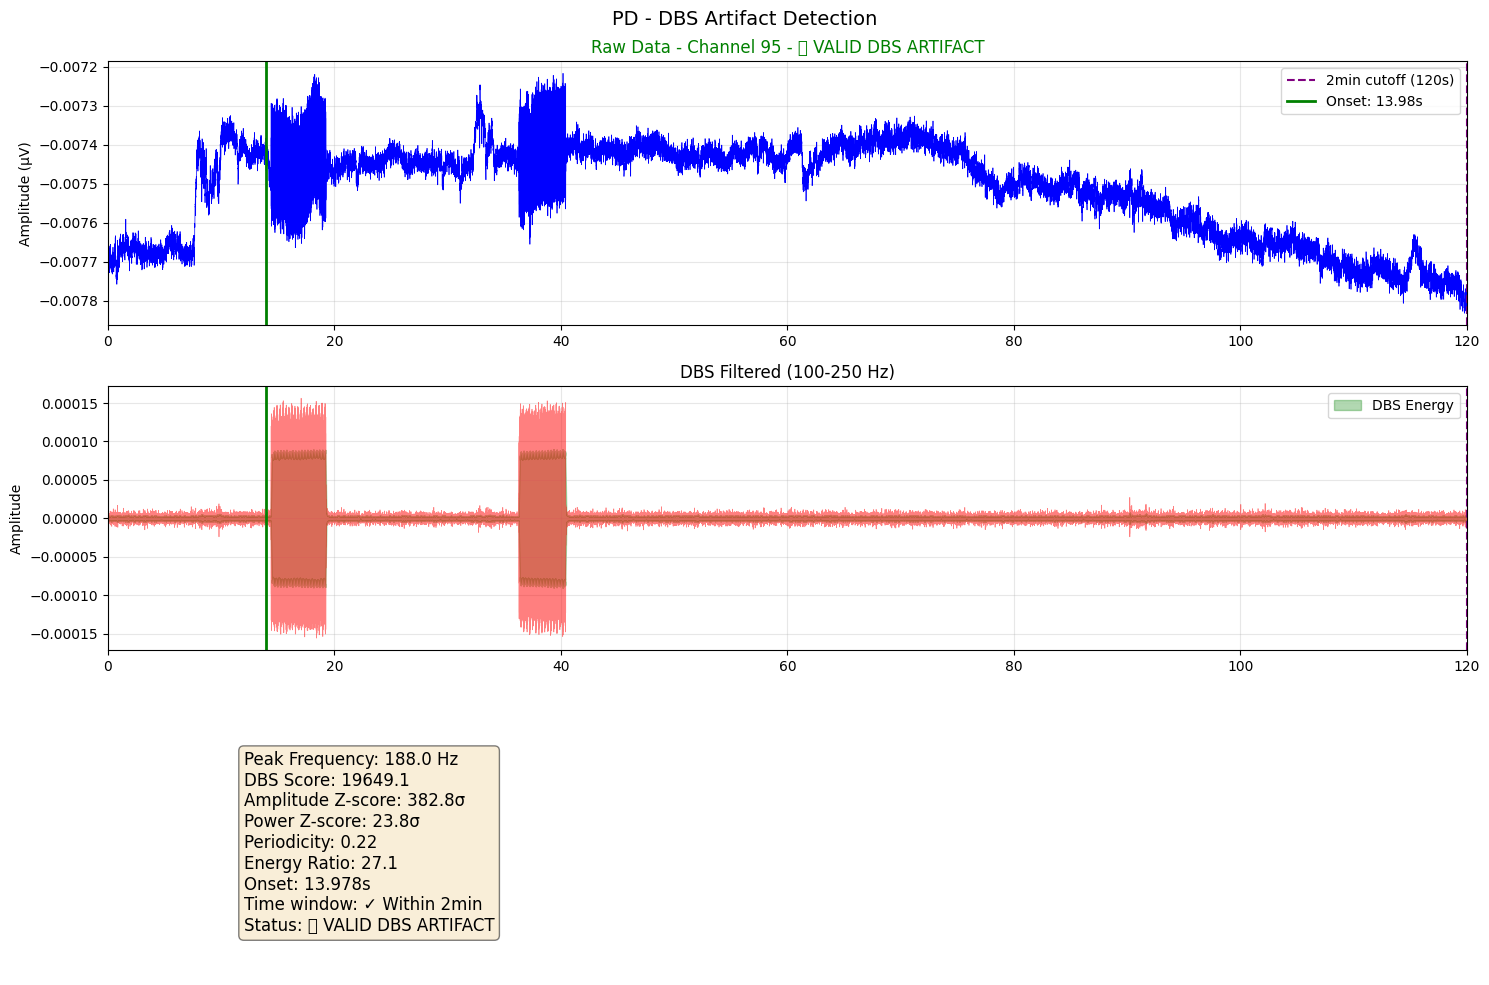


[3/12] Processing: PD_003_rest_hand_foot_DBSOFF.mff
   Sampling rate: 250.0 Hz
   Duration: 684.3s
      DBS range for 250.0Hz: 100-125 Hz

[4/12] Processing: PD_005_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 582.4s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 125.0 Hz, Chan: 95
      Amp Z: 502.7σ, Power Z: 17.6σ
      Periodicity: 0.64, Score: 56280.3
      Onset: 8.578s ✓


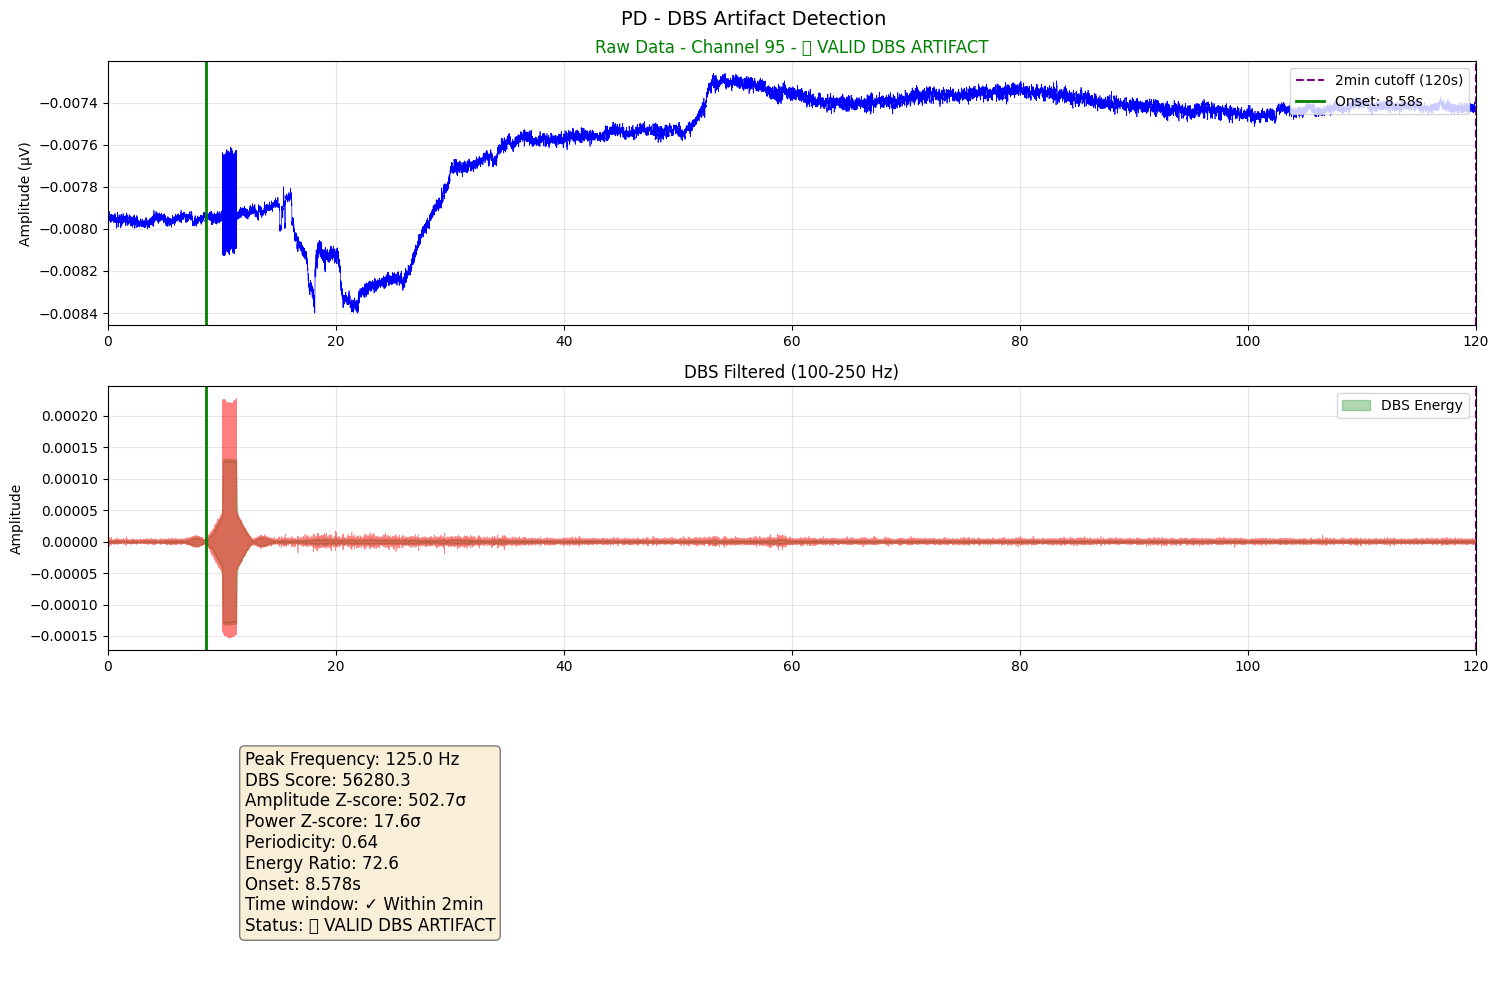


[5/12] Processing: PD_006_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 637.6s
      DBS range for 500.0Hz: 100-250 Hz

   ⚠ CANDIDATE
      Freq: 129.8 Hz, Chan: 88
      Amp Z: 29.1σ, Power Z: 18.3σ
      Periodicity: 0.12, Score: 614.8
      Onset: 48.610s ✓


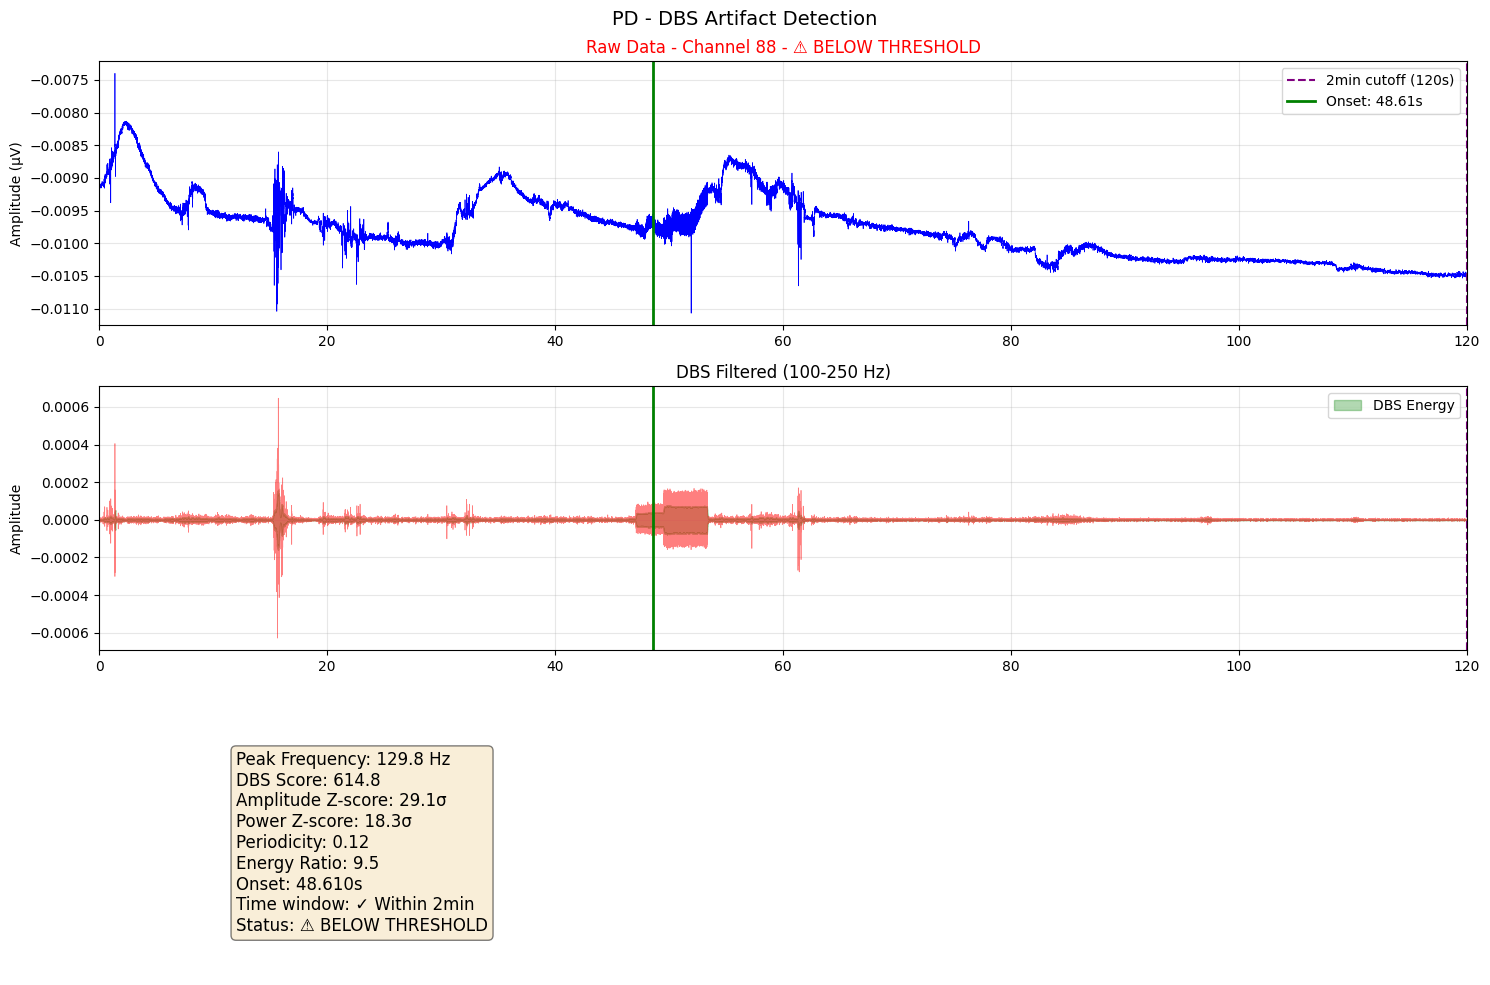


[6/12] Processing: PD_007_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 580.9s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 142.8 Hz, Chan: 224
      Amp Z: 488.6σ, Power Z: 20.2σ
      Periodicity: 0.92, Score: 90961.5
      Onset: 19.576s ✓


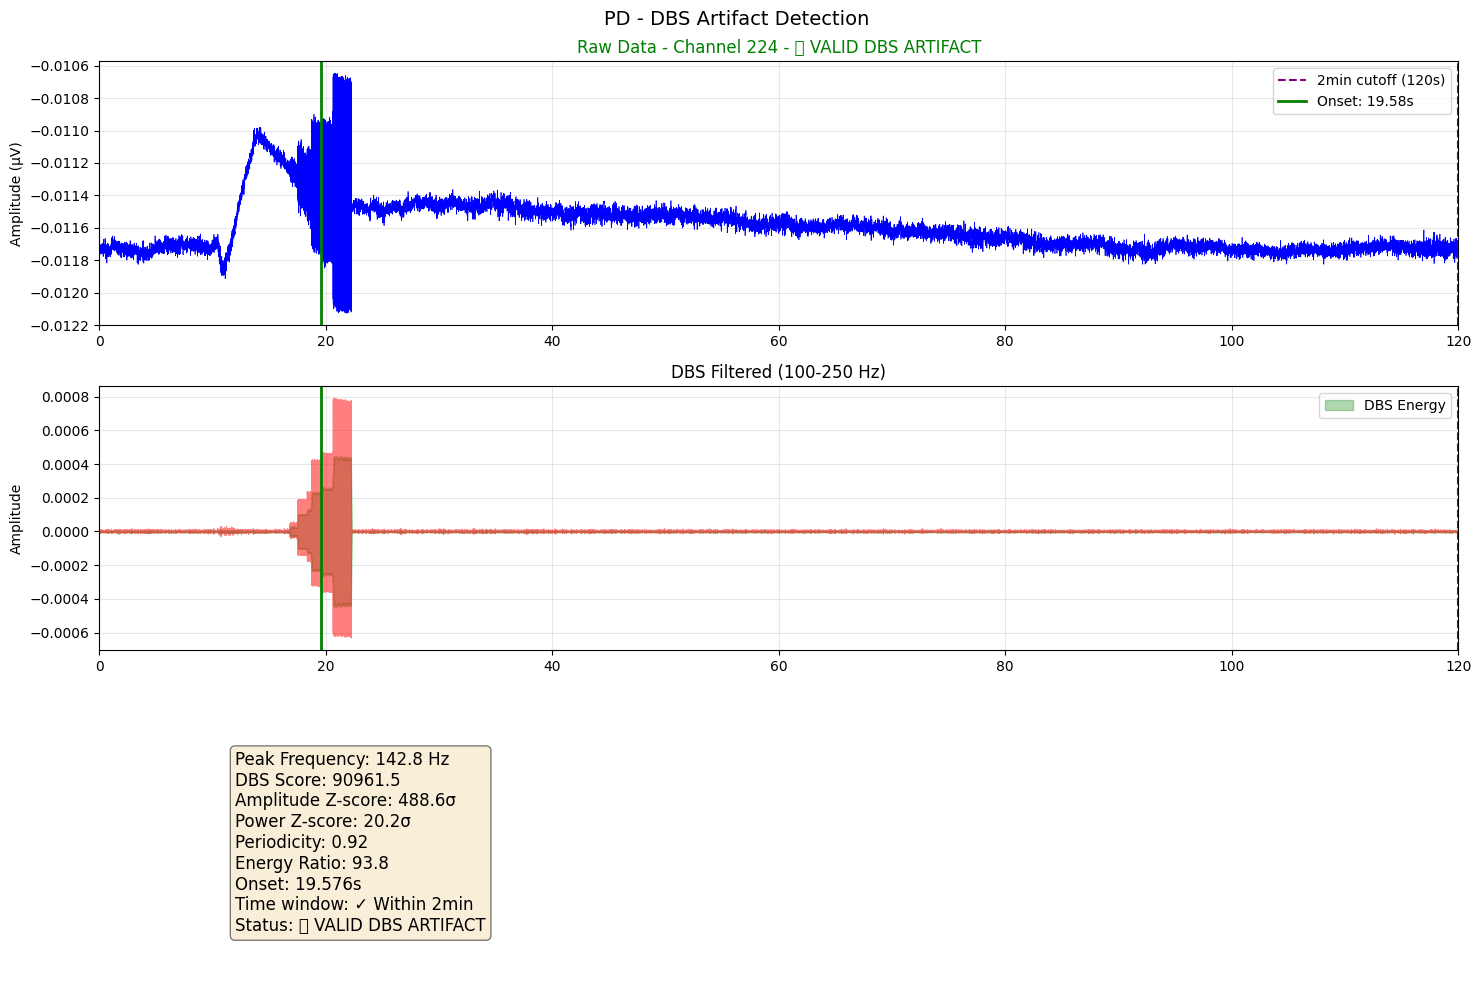


[7/12] Processing: PD_008_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 838.1s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 239.5 Hz, Chan: 95
      Amp Z: 6.8σ, Power Z: 37.0σ
      Periodicity: 0.16, Score: 399.7
      Onset: 34.594s ✓


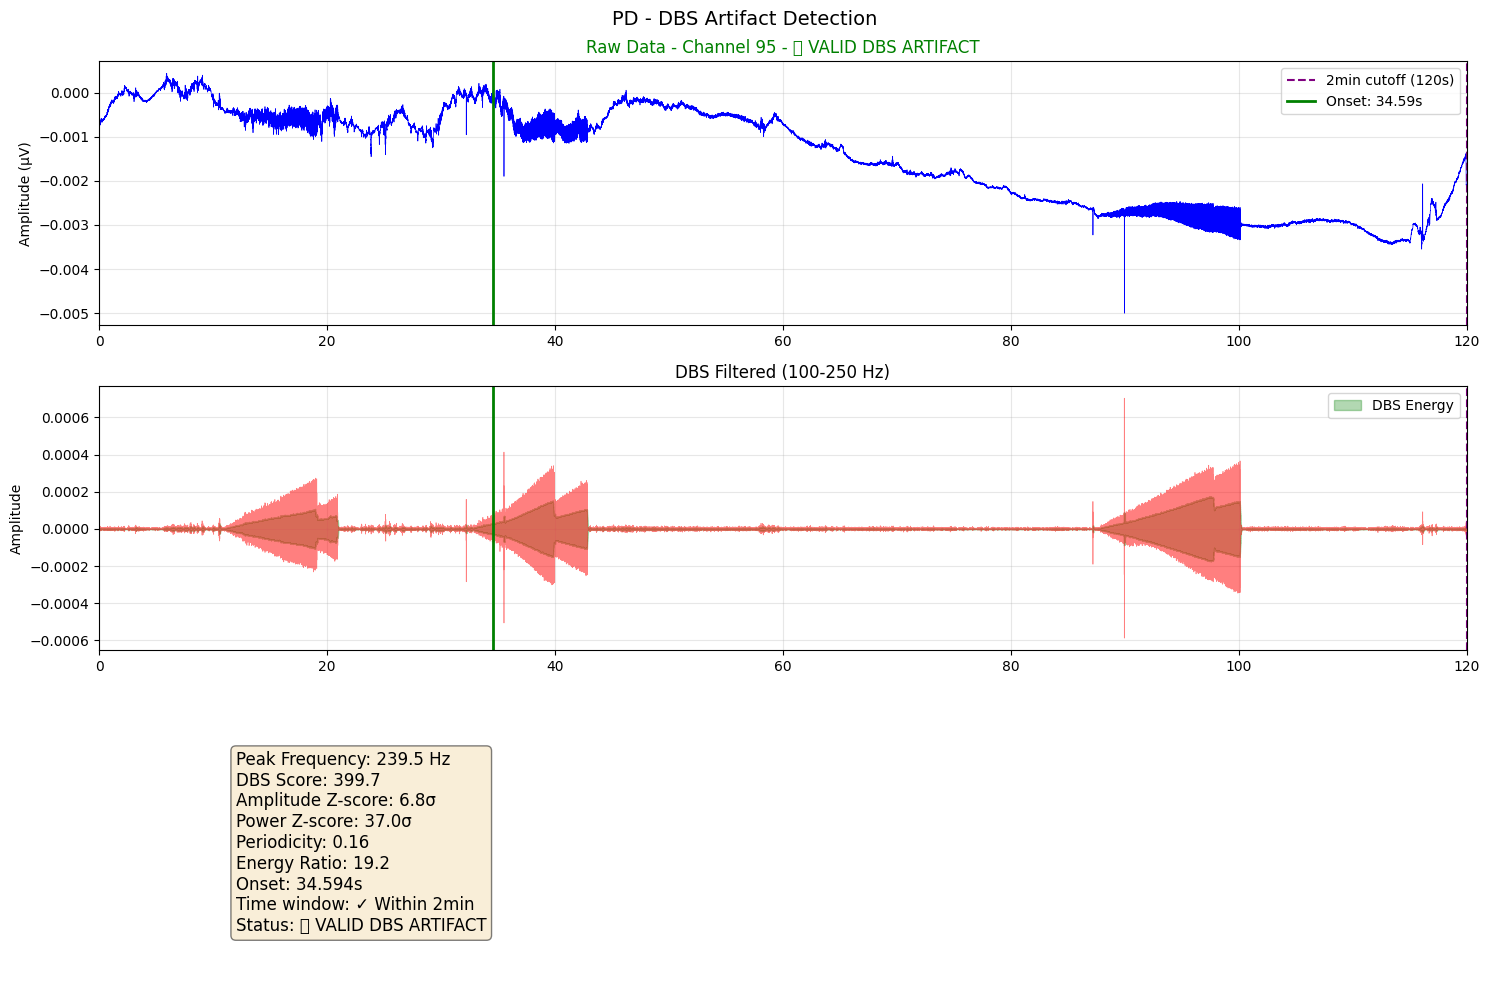


[8/12] Processing: PD_009_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 609.2s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 142.8 Hz, Chan: 90
      Amp Z: 627.5σ, Power Z: 18.4σ
      Periodicity: 0.65, Score: 75032.7
      Onset: 30.780s ✓


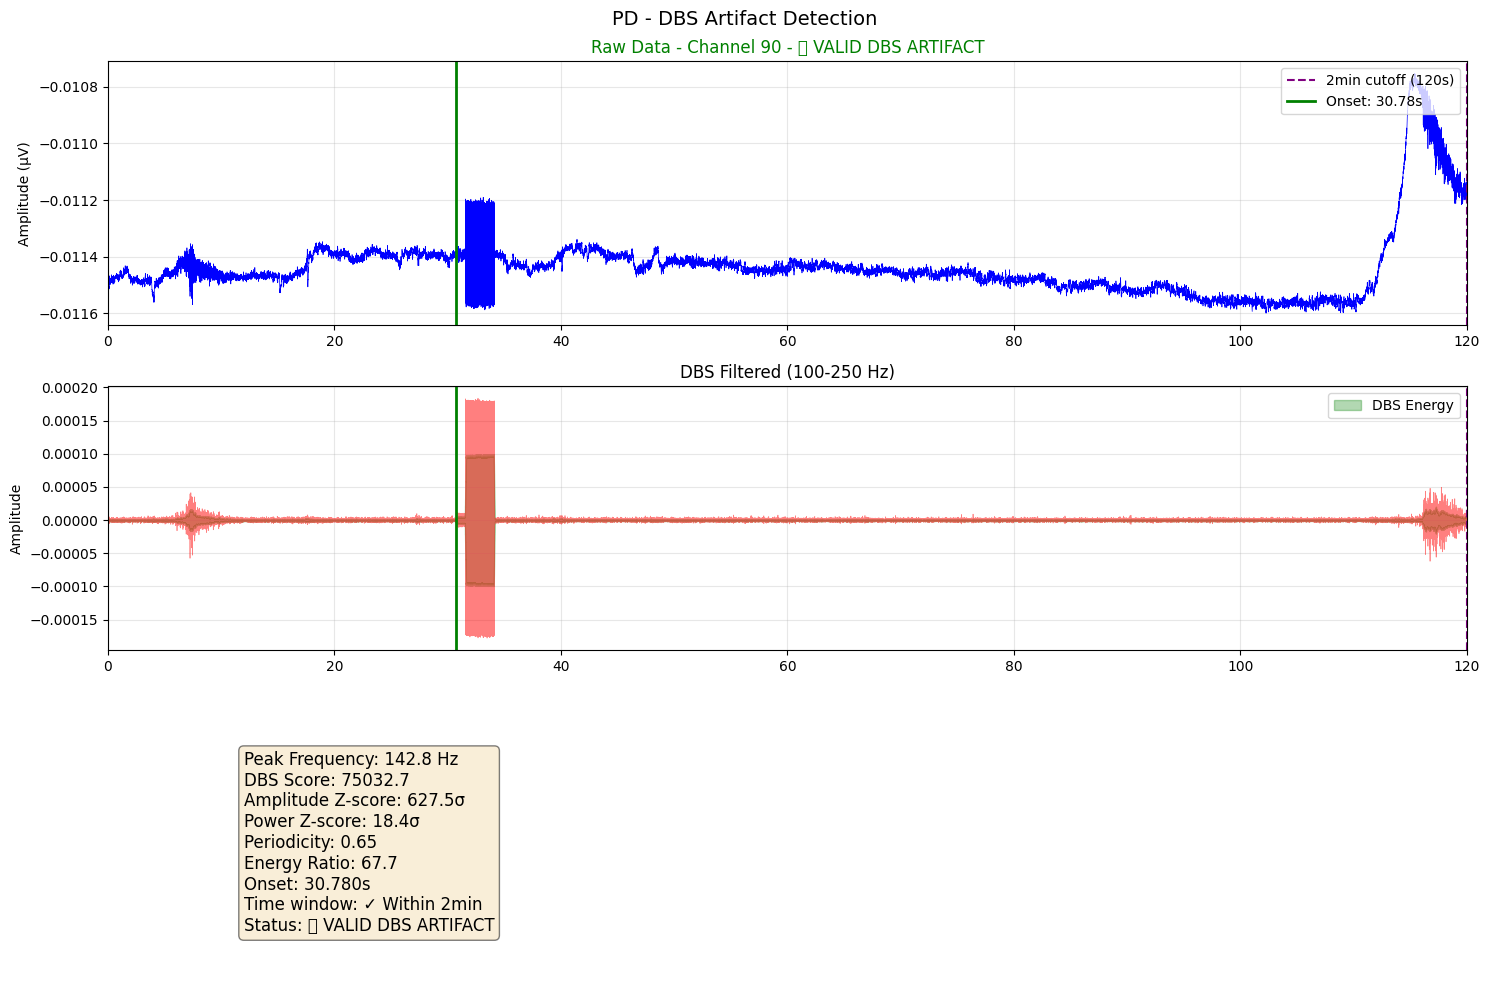


[9/12] Processing: PD_010_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 629.4s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 142.8 Hz, Chan: 221
      Amp Z: 458.5σ, Power Z: 20.1σ
      Periodicity: 0.73, Score: 67608.5
      Onset: 9.294s ✓


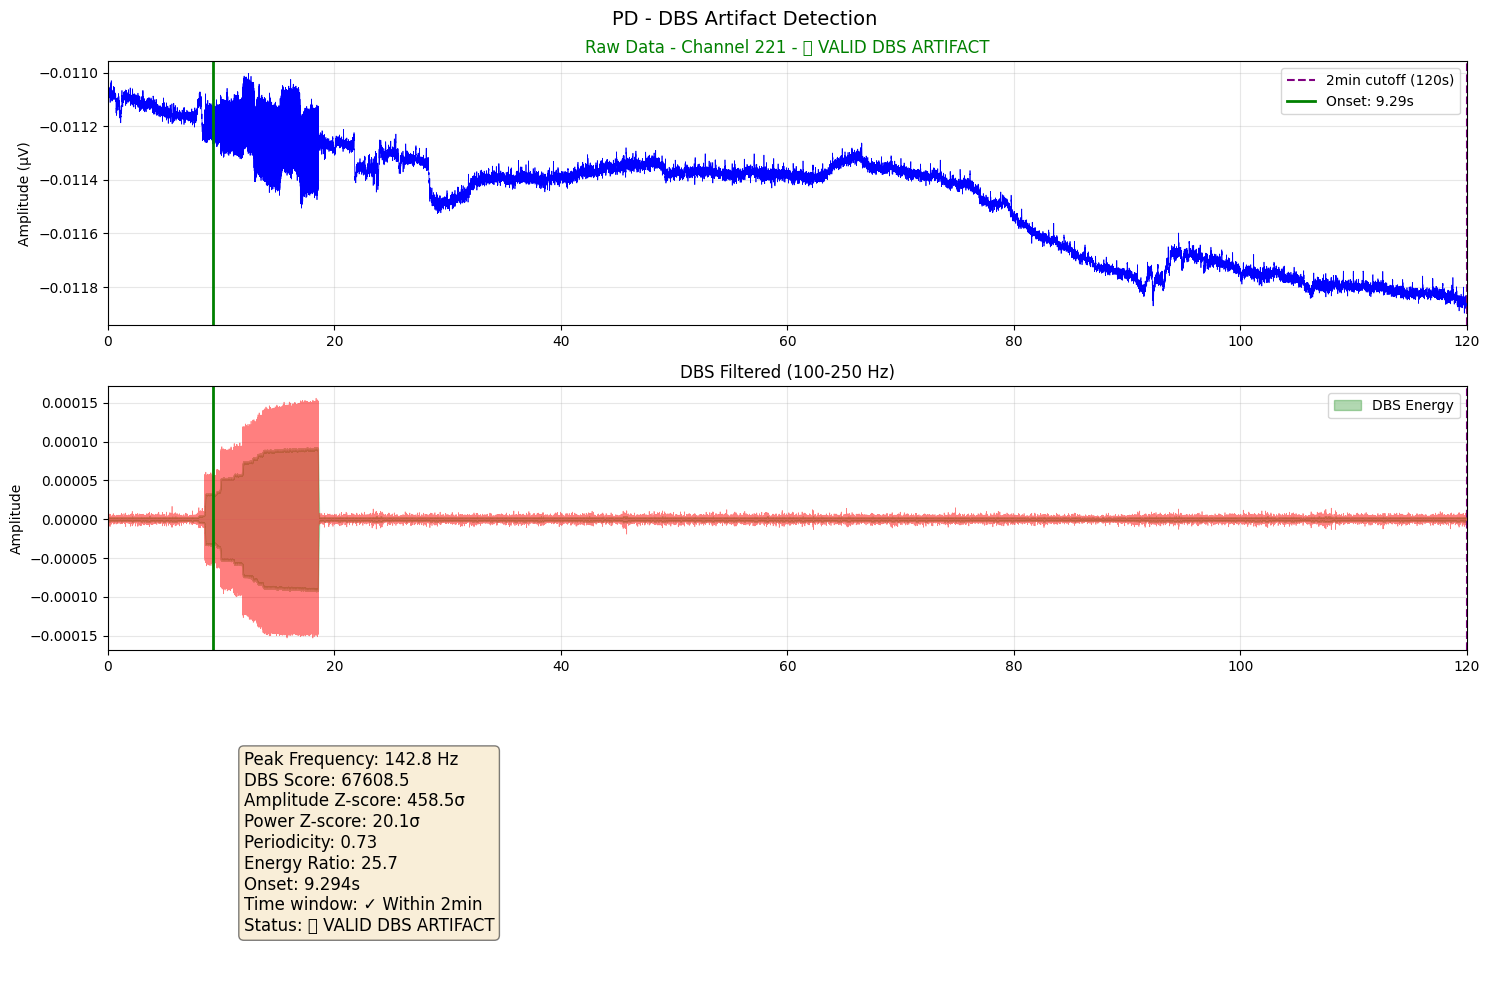


[10/12] Processing: PD_011_rest_hand_foot_DBSOFF.mff
   Sampling rate: 250.0 Hz
   Duration: 608.5s
      DBS range for 250.0Hz: 100-125 Hz

   ⚠ CANDIDATE
      Freq: 125.0 Hz, Chan: 235
      Amp Z: 833.6σ, Power Z: 3.5σ
      Periodicity: 0.12, Score: 3585.2
      Onset: 12.340s ✓


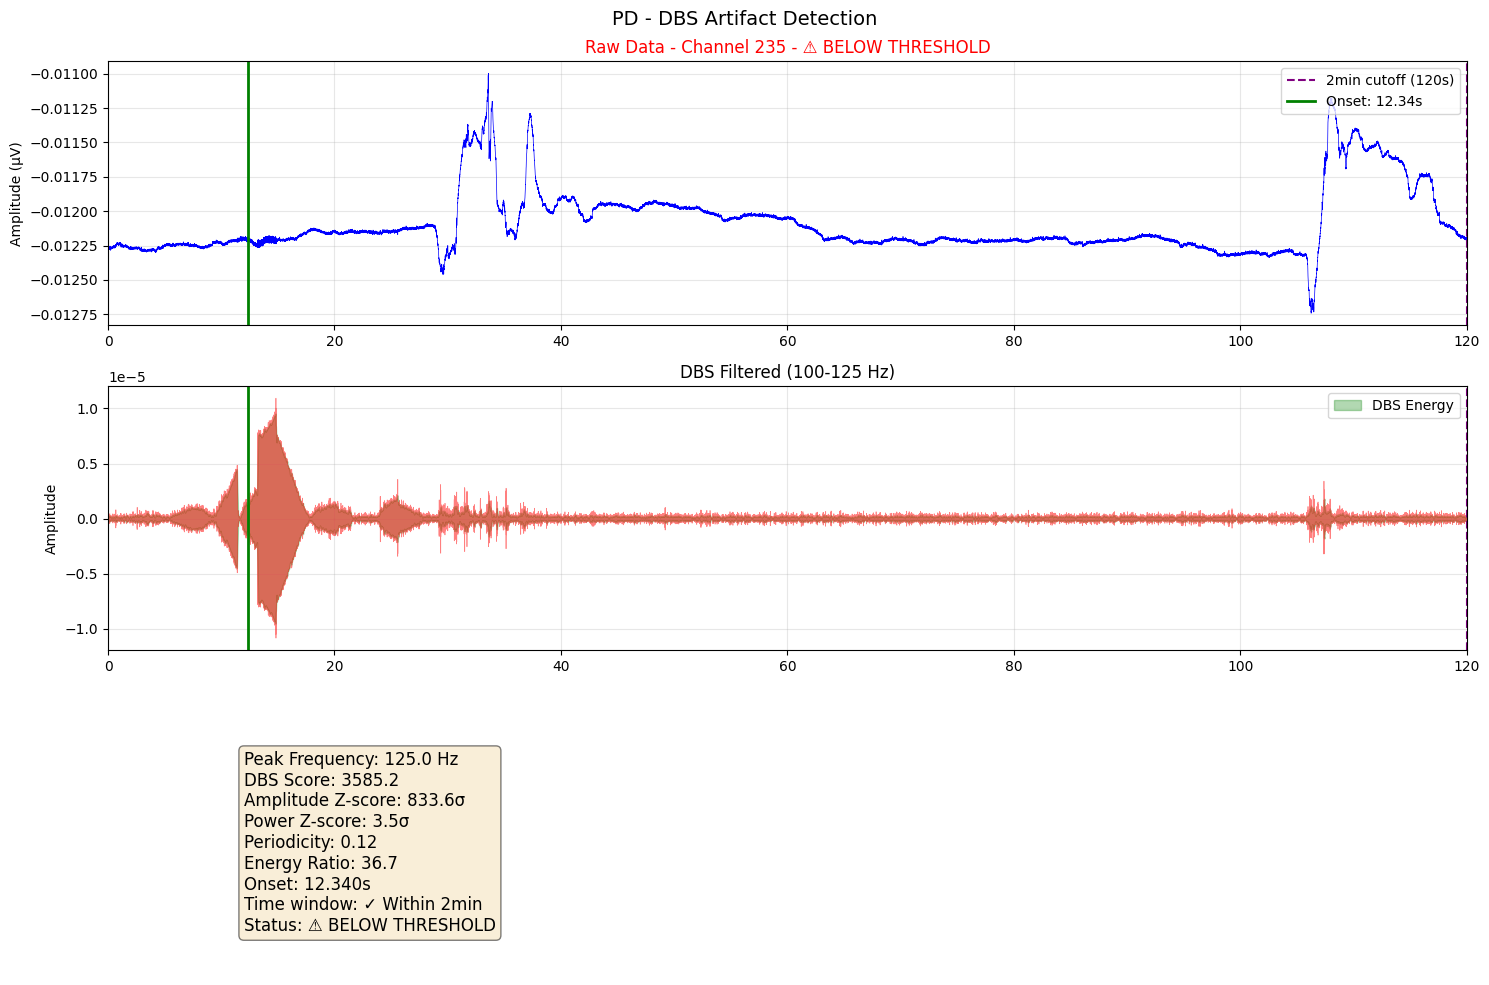


[11/12] Processing: PD_012_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 731.0s
      DBS range for 500.0Hz: 100-250 Hz

   ✅ VALID
      Freq: 130.2 Hz, Chan: 224
      Amp Z: 340.1σ, Power Z: 5.5σ
      Periodicity: 0.15, Score: 2833.1
      Onset: 112.880s ✓


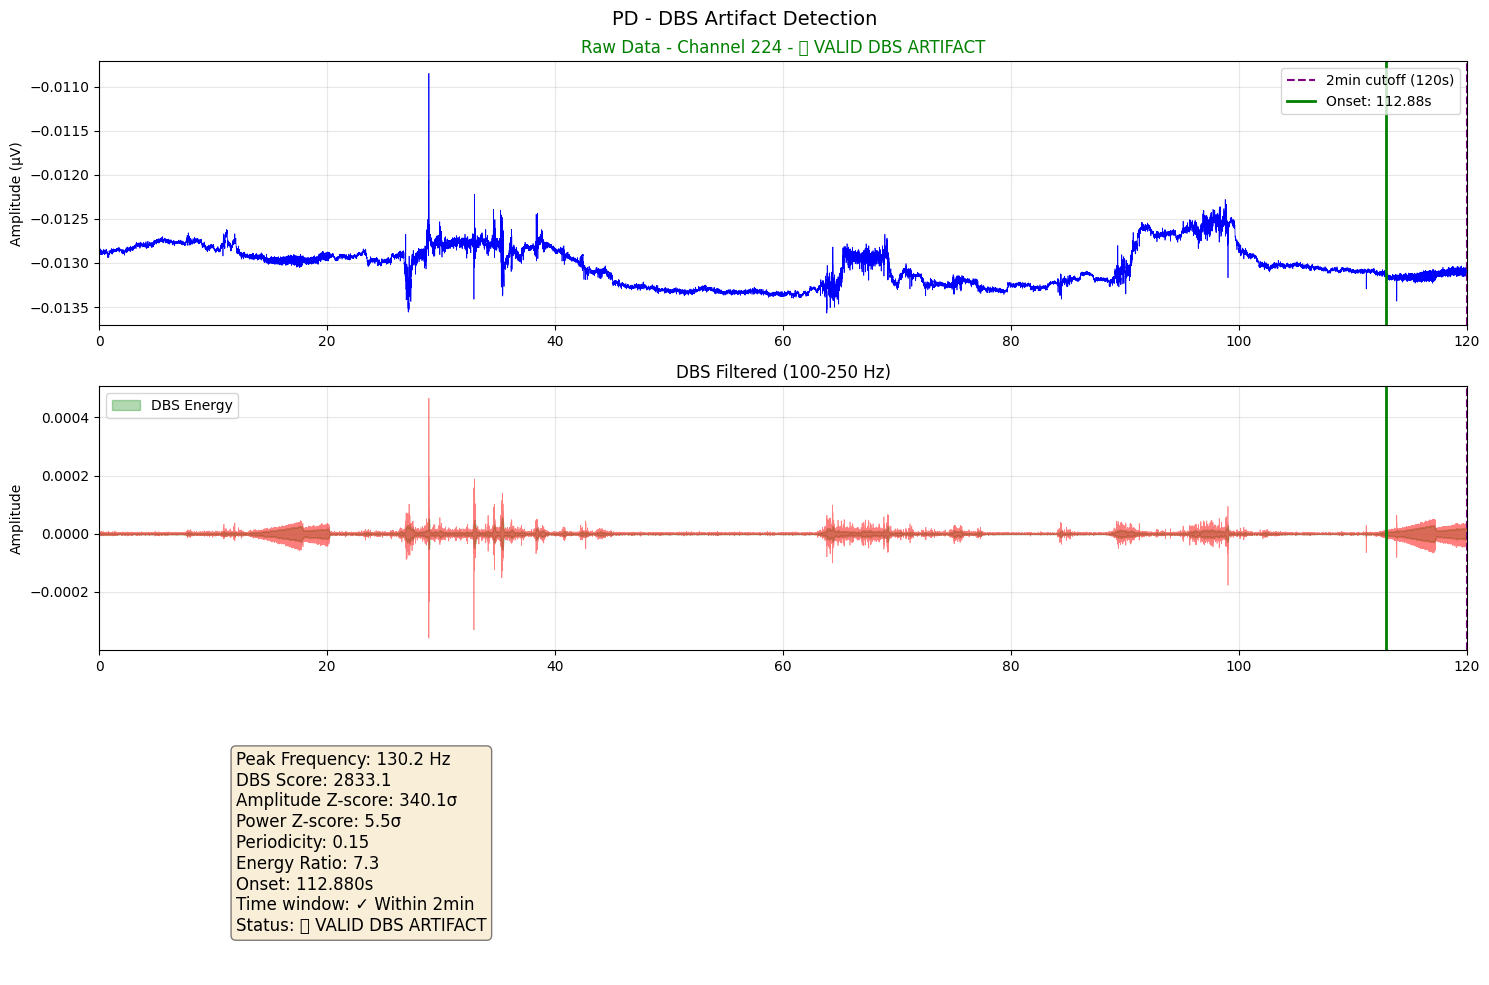


[12/12] Processing: PD_014_rest_hand_foot_DBSOFF.mff
   Sampling rate: 500.0 Hz
   Duration: 771.3s
      DBS range for 500.0Hz: 100-250 Hz

FINAL SUMMARY - COMPLETE METRICS

📊 SUMMARY STATISTICS:
   Total subjects with data: 12
   ✅ VALID artifacts: 7 (58.3%)
   ⚠ CANDIDATES (below threshold): 5 (41.7%)

✅✅✅ VALID DBS ARTIFACTS ✅✅✅
PD_ID    Freq(Hz)   Amp Z      Power Z    Per      Score      Onset(s)  
----------------------------------------------------------------------
   PD       125.0      502.7     σ 17.6      σ 0.64     56280.3    8.58      
   PD       142.8      458.5     σ 20.1      σ 0.73     67608.5    9.29      
   PD       188.0      382.8     σ 23.8      σ 0.22     19649.1    13.98     
   PD       142.8      488.6     σ 20.2      σ 0.92     90961.5    19.58     
   PD       142.8      627.5     σ 18.4      σ 0.65     75032.7    30.78     
   PD       239.5      6.8       σ 37.0      σ 0.16     399.7      34.59     
   PD       130.2      340.1     σ 5.5       σ 0.15 

In [1]:
# FIND DBS STIMULATION ARTIFACTS IN EEG - WORKING VERSION
# Uses sustained amplitude detection with Nyquist limits

import mne
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime
import matplotlib.pyplot as plt
from scipy import stats, signal as scipy_signal
from scipy.signal import welch, find_peaks, butter, filtfilt, correlate
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CONFIGURATION - WORKING PARAMETERS
# =============================================================================

EEG_PATH = Path('/mnt/movement/users/jaizor/xtra/data/eeg/PD_Rest/OFF')
OUTPUT_DIR = Path('/mnt/movement/users/jaizor/xtra/derivatives/eeg_artifacts')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# DBS FREQUENCY RANGE (will be adjusted for Nyquist)
DBS_LOW = 100    # Hz
DBS_HIGH = 250   # Hz
FILTER_ORDER = 4

# ⏱️ TIME WINDOW CONSTRAINT - MUST BE IN FIRST 2 MINUTES
MAX_ONSET_TIME = 120  # seconds (2 minutes)

# =============================================================================
# WORKING THRESHOLDS - These gave 9/12 detection!
# =============================================================================

AMPLITUDE_ZSCORE = 4.0      # Signal must be 4 std devs above baseline
POWER_RATIO_ZSCORE = 3.0    # Power must be 3 std devs above background
PERIODICITY_THRESHOLD = 0.15 # Minimum rhythmicity
DBS_SCORE_THRESHOLD = 20.0   # Combined score threshold

# ONSET DETECTION - Look for SUSTAINED amplitude
MIN_BURST_DURATION = 0.5     # Must last at least 0.5 seconds
ONSET_AMP_MULTIPLIER = 6     # 6σ for detection
ONSET_DERIV_MULTIPLIER = 3   # 3σ for rise
MIN_ONSET_ENERGY = 2.0       # Energy ratio threshold

# Show all candidates for review
SHOW_BAD_CANDIDATES = True

# Stim channels to EXCLUDE (281-288)
STIM_CHANNELS = list(range(280, 289))

# Known mastoid channels
MASTOID_CHANNELS = [
    84, 88, 89, 90, 95, 98,   # left
    221, 223, 224, 225, 234, 235  # right
]

# Subject mapping
SUBJECT_MAP = {
    'PD_001': 'sub-01', 'PD_002': 'sub-02', 'PD_003': 'sub-03',
    'PD_004': 'sub-04', 'PD_005': 'sub-05', 'PD_006': 'sub-06',
    'PD_007': 'sub-07', 'PD_008': 'sub-08', 'PD_009': 'sub-09',
    'PD_010': 'sub-10', 'PD_011': 'sub-11', 'PD_012': 'sub-12',
    'PD_013': 'sub-13', 'PD_014': 'sub-14',
}

# =============================================================================
# Helper functions
# =============================================================================

def get_dbs_range(fs):
    """Get DBS frequency range respecting Nyquist limit"""
    nyquist = fs / 2
    dbs_low = DBS_LOW
    dbs_high = min(DBS_HIGH, nyquist)  # Cap at Nyquist
    return dbs_low, dbs_high

def zscore(data, mean, std):
    """Calculate Z-score: (x - mean) / std"""
    if std == 0:
        return 0
    return (data - mean) / std

def apply_dbs_filter(data, fs):
    """Apply bandpass filter for DBS range (respects Nyquist)"""
    dbs_low, dbs_high = get_dbs_range(fs)
    nyquist = 0.5 * fs
    
    low = dbs_low / nyquist
    high = dbs_high / nyquist
    
    low = max(0.001, min(low, 0.999))
    high = max(0.001, min(high, 0.999))
    
    print(f"      DBS range for {fs}Hz: {dbs_low:.0f}-{dbs_high:.0f} Hz")
    b, a = butter(FILTER_ORDER, [low, high], btype='band')
    filtered = filtfilt(b, a, data, axis=1)
    return filtered

# =============================================================================
# WORKING ONSET DETECTION - Finds SUSTAINED amplitude bursts
# =============================================================================

def find_artifact_onset_working(filtered_data, fs):
    """
    Find when the DBS artifact FIRST appears - looks for SUSTAINED amplitude
    This is the working version that detected 9/12 subjects
    """
    
    # Work with the envelope of the filtered signal
    envelope = np.abs(filtered_data)
    
    # Smoothing windows
    smooth_short = uniform_filter1d(envelope, size=int(fs/20))  # 50ms
    smooth_long = uniform_filter1d(envelope, size=int(fs/2))    # 500ms
    
    # Calculate baseline from first 5 seconds
    baseline_period = int(fs * 5)
    baseline_mean = np.mean(smooth_long[:baseline_period])
    baseline_std = np.std(smooth_long[:baseline_period])
    
    # Calculate derivative
    derivative = np.diff(smooth_short, prepend=smooth_short[0])
    deriv_std = np.std(derivative[:baseline_period])
    
    # ONLY look in first half of recording
    search_limit = min(len(filtered_data) // 2, int(MAX_ONSET_TIME * fs * 2))
    
    # Store ALL potential onsets
    potential_onsets = []
    
    # Scan from 2 seconds to search_limit
    start_scan = int(2 * fs)
    min_burst_samples = int(MIN_BURST_DURATION * fs)
    
    for i in range(start_scan, search_limit - min_burst_samples):
        # Check for significant rise
        if derivative[i] > ONSET_DERIV_MULTIPLIER * deriv_std:
            # Check that amplitude INCREASES and STAYS HIGH
            pre_amp = np.mean(smooth_short[max(0, i-int(fs/5)):i])
            post_amp = np.mean(smooth_short[i:i+int(fs/5)])
            
            if post_amp > pre_amp * 1.3:  # 30% increase
                # Look at SUSTAINED amplitude (not just peak)
                future_end = min(len(smooth_short), i + int(fs * 2))
                sustained_amp = np.mean(smooth_short[i:future_end])
                amp_z = zscore(sustained_amp, baseline_mean, baseline_std)
                
                if amp_z > ONSET_AMP_MULTIPLIER:
                    potential_onsets.append({
                        'sample': i,
                        'time': i / fs,
                        'amp_z': amp_z,
                        'energy_ratio': sustained_amp / baseline_mean if baseline_mean > 0 else 0
                    })
    
    if not potential_onsets:
        return None, None, 0
    
    # Sort by AMPLITUDE Z-SCORE (highest first)
    potential_onsets.sort(key=lambda x: x['amp_z'], reverse=True)
    best = potential_onsets[0]
    
    # Find the true start (look back to where it began rising)
    search_back = max(0, best['sample'] - int(fs))
    pre_burst = smooth_short[search_back:best['sample']]
    
    if len(pre_burst) > 0:
        min_idx = np.argmin(pre_burst)
        true_onset = search_back + min_idx
    else:
        true_onset = best['sample']
    
    onset_time = true_onset / fs
    energy_ratio = best['energy_ratio']
    
    return true_onset, onset_time, energy_ratio

# =============================================================================
# DBS artifact detection - Using Z-scores
# =============================================================================

def detect_dbs_artifacts(data, fs):
    """Detect DBS artifacts using Z-score thresholds"""
    
    n_channels, n_samples = data.shape
    baseline_samples = int(5 * fs)
    
    # Apply DBS filter (respects Nyquist)
    dbs_filtered = apply_dbs_filter(data, fs)
    
    results = []
    
    for ch_idx in MASTOID_CHANNELS:
        if ch_idx >= n_channels or ch_idx in STIM_CHANNELS:
            continue
            
        orig_data = data[ch_idx, :]
        filt_data = dbs_filtered[ch_idx, :]
        
        # Calculate baseline statistics
        baseline = orig_data[:baseline_samples]
        baseline_mean = np.mean(baseline)
        baseline_std = np.std(baseline)
        if baseline_std < 1e-10:
            baseline_std = 1.0
        
        # Amplitude analysis - SUSTAINED amplitude, not just peak
        max_amp = np.max(np.abs(filt_data))
        amp_z = zscore(max_amp, baseline_mean, baseline_std)
        
        # Frequency analysis
        nperseg = min(int(fs * 4), n_samples // 4)
        freqs, psd = welch(orig_data, fs, nperseg=nperseg)
        
        dbs_low, dbs_high = get_dbs_range(fs)
        dbs_range = (freqs >= dbs_low) & (freqs <= dbs_high)
        bg_range = (freqs >= 20) & (freqs <= 200)
        
        if np.any(dbs_range):
            dbs_psd = psd[dbs_range]
            dbs_freqs = freqs[dbs_range]
            peak_idx = np.argmax(dbs_psd)
            peak_freq = dbs_freqs[peak_idx]
            peak_power = dbs_psd[peak_idx]
            
            bg_power = np.mean(psd[bg_range])
            bg_std = np.std(psd[bg_range])
            
            power_z = zscore(peak_power, bg_power, bg_std) if bg_std > 0 else 0
        else:
            peak_freq = 0
            power_z = 0
        
        # Periodicity analysis
        if peak_freq > 0:
            acorr_len = min(int(2 * fs), len(filt_data) // 2)
            acorr_seg = filt_data[:acorr_len]
            
            autocorr = correlate(acorr_seg, acorr_seg, mode='same')
            autocorr = autocorr[len(autocorr)//2:]
            autocorr = autocorr / autocorr[0]
            
            expected_interval = fs / peak_freq
            min_dist = max(1, int(expected_interval * 0.5))
            
            peaks, _ = find_peaks(autocorr, distance=min_dist, height=0.1)
            
            if len(peaks) > 3:
                intervals = np.diff(peaks[:10])
                mean_int = np.mean(intervals)
                std_int = np.std(intervals)
                
                acc = 1 - min(abs(mean_int - expected_interval) / expected_interval, 1)
                cons = 1 - min(std_int / mean_int, 1) if mean_int > 0 else 0
                periodicity = (acc + cons) / 2
            else:
                periodicity = 0
        else:
            periodicity = 0
        
        # Combined score
        dbs_score = amp_z * power_z * (periodicity * 10)
        
        results.append({
            'channel': ch_idx,
            'channel_name': f'Mastoid_{ch_idx+1}',
            'peak_freq': peak_freq,
            'amp_z': amp_z,
            'power_z': power_z,
            'periodicity': periodicity,
            'dbs_score': dbs_score,
            'filtered_data': filt_data
        })
    
    # Find best channel
    results_df = pd.DataFrame(results)
    best_idx = results_df['dbs_score'].idxmax()
    best = results_df.loc[best_idx].to_dict()
    
    # Determine if artifact
    meets_criteria = (best['amp_z'] > AMPLITUDE_ZSCORE and
                      best['power_z'] > POWER_RATIO_ZSCORE and
                      best['periodicity'] > PERIODICITY_THRESHOLD and
                      best['dbs_score'] > DBS_SCORE_THRESHOLD)
    
    return results_df, best, meets_criteria

# =============================================================================
# Visualization
# =============================================================================

def plot_results_working(orig_data, filt_data, fs, channel, peak_freq, 
                         onset_time, energy_ratio, pd_id, metrics, 
                         meets_criteria, in_time_window):
    """Create diagnostic plot"""
    
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))
    time = np.arange(len(orig_data)) / fs
    
    # Determine status
    if meets_criteria and in_time_window:
        status = "✅ VALID DBS ARTIFACT"
        title_color = 'green'
    elif meets_criteria and not in_time_window:
        status = "⚠ GOOD BUT TOO LATE (>2min)"
        title_color = 'orange'
    else:
        status = "⚠ BELOW THRESHOLD"
        title_color = 'red'
    
    # Raw data
    ax = axes[0]
    n = int(min(120*fs, len(orig_data)))
    ax.plot(time[:n], orig_data[:n], 'b-', linewidth=0.5)
    ax.axvline(MAX_ONSET_TIME, color='purple', linestyle='--', 
               label=f'2min cutoff ({MAX_ONSET_TIME}s)')
    
    if onset_time and onset_time <= n/fs:
        color = 'green' if onset_time <= MAX_ONSET_TIME else 'orange'
        ax.axvline(onset_time, color=color, linewidth=2, 
                  label=f'Onset: {onset_time:.2f}s')
    
    ax.set_title(f'Raw Data - Channel {channel} - {status}', color=title_color)
    ax.set_ylabel('Amplitude (µV)')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(120, len(orig_data)/fs)])
    
    # Filtered data with envelope
    ax = axes[1]
    ax.plot(time[:n], filt_data[:n], 'r-', linewidth=0.5, alpha=0.5)
    
    envelope = np.abs(filt_data)
    smooth_env = uniform_filter1d(envelope, size=int(fs/10))
    ax.fill_between(time[:n], -smooth_env[:n], smooth_env[:n], 
                    color='green', alpha=0.3, label='DBS Energy')
    
    ax.axvline(MAX_ONSET_TIME, color='purple', linestyle='--')
    if onset_time and onset_time <= n/fs:
        ax.axvline(onset_time, color=color, linewidth=2)
    
    dbs_low, dbs_high = get_dbs_range(fs)
    ax.set_title(f'DBS Filtered ({dbs_low:.0f}-{dbs_high:.0f} Hz)')
    ax.set_ylabel('Amplitude')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, min(120, len(orig_data)/fs)])
    
    # Metrics
    ax = axes[2]
    ax.axis('off')
    
    time_status = "✓ Within 2min" if in_time_window else "✗ After 2min"
    onset_str = f"{onset_time:.3f}s" if onset_time else "Not detected"
    
    text = (f"Peak Frequency: {peak_freq:.1f} Hz\n"
            f"DBS Score: {metrics['dbs_score']:.1f}\n"
            f"Amplitude Z-score: {metrics['amp_z']:.1f}σ\n"
            f"Power Z-score: {metrics['power_z']:.1f}σ\n"
            f"Periodicity: {metrics['periodicity']:.2f}\n"
            f"Energy Ratio: {energy_ratio:.1f}\n"
            f"Onset: {onset_str}\n"
            f"Time window: {time_status}\n"
            f"Status: {status}")
    
    ax.text(0.1, 0.5, text, fontsize=12, verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.suptitle(f'{pd_id} - DBS Artifact Detection', fontsize=14)
    plt.tight_layout()
    return fig

# =============================================================================
# Main processing
# =============================================================================

print("="*80)
print("FINDING DBS STIMULATION ARTIFACTS - WORKING VERSION")
print("="*80)
print(f"Base DBS range: {DBS_LOW}-{DBS_HIGH} Hz (adjusted for Nyquist)")
print(f"⏱️  MUST OCCUR IN FIRST {MAX_ONSET_TIME} SECONDS")
print(f"Amplitude Z-score: {AMPLITUDE_ZSCORE}σ")
print(f"Power Z-score: {POWER_RATIO_ZSCORE}σ")
print(f"Periodicity: {PERIODICITY_THRESHOLD}")
print(f"Min burst duration: {MIN_BURST_DURATION}s")
print("="*80)

mff_folders = sorted([f for f in EEG_PATH.iterdir() if f.is_dir() and f.suffix == '.mff'])
print(f"Found {len(mff_folders)} EEG recordings")

all_results = []

for i, mff_path in enumerate(mff_folders):
    print(f"\n[{i+1}/{len(mff_folders)}] Processing: {mff_path.name}")
    
    try:
        raw = mne.io.read_raw_egi(str(mff_path), preload=True, verbose=False)
        fs = raw.info['sfreq']
        data = raw.get_data()
        
        pd_id = mff_path.name.split('_')[0]
        subject = SUBJECT_MAP.get(pd_id, 'unknown')
        
        print(f"   Sampling rate: {fs} Hz")
        print(f"   Duration: {data.shape[1]/fs:.1f}s")
        
        results_df, best, meets_criteria = detect_dbs_artifacts(data, fs)
        results_df.to_csv(OUTPUT_DIR / f'{pd_id}_dbs_analysis.csv', index=False)
        
        onset_sample, onset_time, energy_ratio = None, None, 0
        if best['filtered_data'] is not None:
            onset_sample, onset_time, energy_ratio = find_artifact_onset_working(
                best['filtered_data'], fs
            )
        
        in_time_window = onset_time is not None and onset_time <= MAX_ONSET_TIME
        is_valid_artifact = meets_criteria and in_time_window
        
        if is_valid_artifact or meets_criteria or (SHOW_BAD_CANDIDATES and best['dbs_score'] > 5):
            status_str = "✅ VALID" if is_valid_artifact else "⚠ CANDIDATE"
            print(f"\n   {status_str}")
            print(f"      Freq: {best['peak_freq']:.1f} Hz, Chan: {best['channel']}")
            print(f"      Amp Z: {best['amp_z']:.1f}σ, Power Z: {best['power_z']:.1f}σ")
            print(f"      Periodicity: {best['periodicity']:.2f}, Score: {best['dbs_score']:.1f}")
            if onset_time:
                print(f"      Onset: {onset_time:.3f}s {'✓' if in_time_window else '✗'}")
            
            fig = plot_results_working(
                data[int(best['channel'])], best['filtered_data'], fs,
                int(best['channel']), best['peak_freq'],
                onset_time, energy_ratio, pd_id, best,
                meets_criteria, in_time_window
            )
            
            plot_name = f'{pd_id}_dbs_artifact.png' if is_valid_artifact else f'{pd_id}_dbs_candidate.png'
            fig.savefig(OUTPUT_DIR / plot_name, dpi=150, bbox_inches='tight')
            plt.show()
            plt.close(fig)
        
        all_results.append({
            'pd_id': pd_id, 'subject': subject, 'has_artifact': is_valid_artifact,
            'meets_criteria': meets_criteria, 'in_time_window': in_time_window,
            'peak_freq': best['peak_freq'], 'channel': int(best['channel']),
            'amp_z': best['amp_z'], 'power_z': best['power_z'],
            'periodicity': best['periodicity'], 'dbs_score': best['dbs_score'],
            'onset_time': onset_time if onset_time else -1
        })
            
    except Exception as e:
        print(f"   ❌ Error: {e}")
        traceback.print_exc()

# =============================================================================
# FIXED SUMMARY - Shows ALL metrics
# =============================================================================

print("\n" + "="*80)
print("FINAL SUMMARY - COMPLETE METRICS")
print("="*80)

if all_results:
    df = pd.DataFrame(all_results)
    df = df[df['peak_freq'] > 0]
    df.to_csv(OUTPUT_DIR / 'dbs_artifact_summary_complete.csv', index=False)
    
    n_valid = df['has_artifact'].sum()
    n_candidates = len(df[df['meets_criteria'] == False])
    
    print(f"\n📊 SUMMARY STATISTICS:")
    print(f"   Total subjects with data: {len(df)}")
    print(f"   ✅ VALID artifacts: {n_valid} ({n_valid/len(df)*100:.1f}%)")
    print(f"   ⚠ CANDIDATES (below threshold): {n_candidates} ({n_candidates/len(df)*100:.1f}%)")
    
    # Show VALID artifacts with full metrics
    if n_valid > 0:
        print(f"\n✅✅✅ VALID DBS ARTIFACTS ✅✅✅")
        print(f"{'PD_ID':<8} {'Freq(Hz)':<10} {'Amp Z':<10} {'Power Z':<10} {'Per':<8} {'Score':<10} {'Onset(s)':<10}")
        print("-" * 70)
        for _, row in df[df['has_artifact']].sort_values('onset_time').iterrows():
            print(f"   {row['pd_id']:<8} {row['peak_freq']:<10.1f} "
                  f"{row['amp_z']:<10.1f}σ {row['power_z']:<10.1f}σ "
                  f"{row['periodicity']:<8.2f} {row['dbs_score']:<10.1f} "
                  f"{row['onset_time']:<10.2f}")
    
    # Show CANDIDATES that almost made it
    candidates = df[df['meets_criteria'] == False]
    if len(candidates) > 0:
        print(f"\n⚠️⚠️⚠️ CANDIDATES (BELOW THRESHOLD) ⚠️⚠️⚠️")
        print(f"{'PD_ID':<8} {'Freq(Hz)':<10} {'Amp Z':<10} {'Power Z':<10} {'Per':<8} {'Score':<10} {'Onset(s)':<10}")
        print("-" * 70)
        for _, row in candidates.sort_values('dbs_score', ascending=False).iterrows():
            # Mark which threshold failed
            fails = []
            if row['amp_z'] <= AMPLITUDE_ZSCORE:
                fails.append('Amp')
            if row['power_z'] <= POWER_RATIO_ZSCORE:
                fails.append('Power')
            if row['periodicity'] <= PERIODICITY_THRESHOLD:
                fails.append('Per')
            if row['dbs_score'] <= DBS_SCORE_THRESHOLD:
                fails.append('Score')
            fail_str = f" (fails: {', '.join(fails)})"
            
            print(f"   {row['pd_id']:<8} {row['peak_freq']:<10.1f} "
                  f"{row['amp_z']:<10.1f}σ {row['power_z']:<10.1f}σ "
                  f"{row['periodicity']:<8.2f} {row['dbs_score']:<10.1f} "
                  f"{row['onset_time']:<10.2f}{fail_str}")
    
    # Show ALL subjects sorted by score
    print(f"\n📋 ALL SUBJECTS (sorted by DBS Score):")
    print(f"{'Status':<8} {'PD_ID':<8} {'Freq(Hz)':<10} {'Amp Z':<10} {'Power Z':<10} {'Per':<8} {'Score':<10} {'Onset(s)':<10}")
    print("-" * 80)
    for _, row in df.sort_values('dbs_score', ascending=False).iterrows():
        status = "✅" if row['has_artifact'] else "⚠"
        onset_display = f"{row['onset_time']:.2f}" if row['onset_time'] > 0 else "None"
        print(f"   {status:<8} {row['pd_id']:<8} {row['peak_freq']:<10.1f} "
              f"{row['amp_z']:<10.1f}σ {row['power_z']:<10.1f}σ "
              f"{row['periodicity']:<8.2f} {row['dbs_score']:<10.1f} "
              f"{onset_display:<10}")

print("\n" + "="*80)
print("✅ PROCESSING COMPLETE - Check CSV for full details")
print("="*80)